# Working with `kopya` results

This notebook walks through **every file** that `kopya run` writes and
shows how to turn them into your own analysis. It runs against the committed
example results in [`examples/tiny_simulated/`](../examples/tiny_simulated),
produced from a 500-cell simulated dataset with three planted events:

| Event | Truth |
|-------|-------|
| **chr7** | whole-chromosome **gain** (2.5×) |
| **chr10** | whole-chromosome **loss** (0.4×) |
| **MYC (chr8)** | focal **amplification** (5×) |

200 cells are normal, 300 are tumor. Because we know the ground truth, this is
a good place to build intuition for what the numbers *mean*.

> **The one thing to remember about scale.** The pipeline works in
> **natural-log expression space**, not DNA copy number. Inputs are raw UMI
> counts, normalized to CP10k and `log1p`, then each gene is centered against
> the normal-cell median. So the "CNV signal" is a *relative log-expression
> deviation*: **0 = diploid-like, positive = gain, negative = loss**, and
> **negative values are normal and expected**. It is a proxy for copy number,
> not a literal copy-number call.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the example directory whether this notebook is run from the repo root
# or from the notebooks/ directory.
_here = Path.cwd()
CANDIDATES = [
    _here / "examples" / "tiny_simulated",
    _here.parent / "examples" / "tiny_simulated",
]
RUN_DIR = next((p for p in CANDIDATES if p.exists()), None)
assert RUN_DIR is not None, f"Could not find examples/tiny_simulated near {_here}"
# Show a repo-relative path so the notebook renders the same wherever it runs.
try:
    _shown = RUN_DIR.relative_to(_here if (_here / "examples").exists() else _here.parent)
except ValueError:
    _shown = RUN_DIR
print("Reading results from:", _shown)
print("Files:", sorted(p.name for p in RUN_DIR.iterdir()))

Reading results from: examples/tiny_simulated
Files: ['chr_cnv_matrix.csv', 'cn_per_segment.npz', 'cn_per_segment_denoised.npz', 'heatmap.png', 'prediction.csv', 'qc.json', 'segments.parquet', 'tiny_simulated_clones.seg']


## 1. `prediction.csv`: the per-cell call

One row per cell barcode. This is the file most users start (and often stop)
with. Columns:

| Column | Meaning |
|--------|---------|
| `class` | `tumor` / `normal` / `uncertain`: the final call |
| `confidence` | GMM posterior for the call, in `[0, 1]` (see caveat below) |
| `tumor_score` | total absolute CNV deviation ("aneuploidy load"), see §1.1 |
| `subclone` | `subclone_1…N` for tumor cells (largest = `subclone_1`); `""` otherwise |
| `n_segments_altered` | number of segments with \|deviation\| > 0.2 log-units |
| `low_complexity` | `True` if the cell has too few detected genes to trust |

In [2]:
pred = pd.read_csv(RUN_DIR / "prediction.csv", index_col="barcode")
print(pred["class"].value_counts().to_dict())
pred.head()

{'tumor': 300, 'normal': 200}


,class,confidence,tumor_score,subclone,n_segments_altered,low_complexity
barcode,,,,,,
cell_0000,normal,1.0,3.526444,NaN,2,False
cell_0001,normal,1.0,4.184726,NaN,2,False
cell_0002,normal,1.0,4.177427,NaN,6,False
cell_0003,normal,1.0,4.011363,NaN,3,False
cell_0004,normal,1.0,3.289232,NaN,4,False


### 1.1 What `tumor_score` is (and is not)

`tumor_score` is the **L1 distance** of a cell's per-segment CN vector from the
normal-pool baseline, literally the *sum of absolute deviations across all
segments*. Think of it as an **aneuploidy load**: near 0 for normal cells,
larger for cells carrying more/stronger CNV events.

**It is not a probability, a z-score, or a fixed-unit quantity.** Its magnitude
scales with the number of segments and the signal strength of *this* run, so a
`tumor_score` of 25 in one sample is **not comparable** to 25 in another. Use it
to *rank* cells within a run, not to threshold across runs. For a portable
"how altered is this cell" measure, prefer **`n_segments_altered`**.

The tumor/normal split is made by a 2-component Gaussian mixture on this score,
so the two classes separate into two humps:

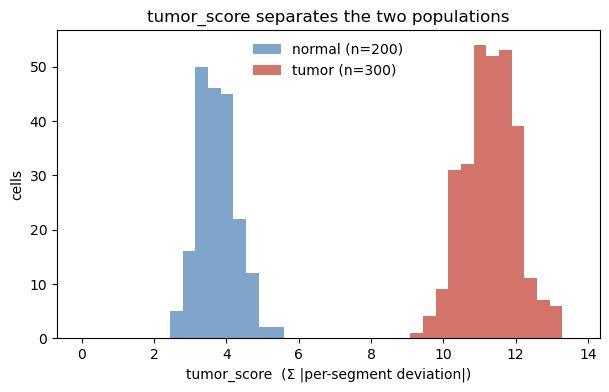

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, pred["tumor_score"].quantile(0.999), 40)
for cls, color in [("normal", "#4a7fb5"), ("tumor", "#c0392b"), ("uncertain", "#e0a020")]:
    s = pred.loc[pred["class"] == cls, "tumor_score"]
    if len(s):
        ax.hist(s, bins=bins, alpha=0.7, color=color, label=f"{cls} (n={len(s)})")
ax.set_xlabel("tumor_score  (Σ |per-segment deviation|)")
ax.set_ylabel("cells")
ax.set_title("tumor_score separates the two populations")
ax.legend(frameon=False)
plt.show()

**On `confidence`:** it is the maximum GMM posterior for the cell's call. Cells
below `--call-confidence` (default 0.5) are reported as `uncertain`. One
subtlety: when a quality gate (low-complexity or incoherent-signal) *downgrades*
a tumor call to uncertain, the reported confidence is rewritten to `1 − posterior`
so that gated cells always read as low-confidence. In short: **high confidence +
a `tumor`/`normal` class = a call you can trust; `uncertain` = the tool declined
to decide.**

## 2. `segments.parquet`: the segment-to-genome map

The genome is broken into contiguous **segments** of co-varying signal. This
table is the key to *reusing* the numeric matrices, because it tells you where
each segment lives. One row per segment, in genome order:

| Column | Meaning |
|--------|---------|
| `segment_id` | 0-based key; **row `i` here == column `i`** of `cn_per_segment.npz` |
| `chr` | chromosome |
| `start_idx`, `end_idx` | gene-axis indices (start inclusive, end **exclusive**) |
| `start_bp`, `end_bp` | **genomic coordinates** (bp) of the segment's first/last gene |
| `n_genes` | genes in the segment |
| `tumor_mean` | pooled-tumor mean log-deviation (>0 gain, <0 loss) |

> `start_bp` / `end_bp` are new: they make `segments.parquet` a self-contained
> *segment-to-chromosome-location* mapping, so you never need the original
> `adata.var` to know where a segment is.

In [4]:
seg = pd.read_parquet(RUN_DIR / "segments.parquet")
print(f"{len(seg)} segments across {seg['chr'].nunique()} chromosomes")
seg.head()

45 segments across 22 chromosomes


,chr,start_idx,end_idx,n_genes,tumor_mean,segment_id,start_bp,end_bp
0,chr1,0,35,35,-0.125607,0,1296110,43931014
1,chr1,35,98,63,-0.108583,1,46607719,167427345
2,chr1,98,154,56,-0.097628,2,167379108,248698932
3,chr2,154,179,25,-0.097557,3,217730,47272603
4,chr2,179,262,83,-0.095826,4,49563344,242084748


The planted events fall straight out of `tumor_mean`: chr7 segments are the
strongest gains, chr10 the strongest losses:

In [5]:
chr_signal = seg.groupby("chr")["tumor_mean"].mean().sort_values()
print("Strongest losses (most negative tumor_mean):")
print(chr_signal.head(3).round(3))
print("\nStrongest gains (most positive tumor_mean):")
print(chr_signal.tail(3).round(3))

Strongest losses (most negative tumor_mean):
chr
chr10   -1.085
chr13   -0.120
chr11   -0.118
Name: tumor_mean, dtype: float64

Strongest gains (most positive tumor_mean):
chr
chr22   -0.080
chr7     0.579
chr8     1.265
Name: tumor_mean, dtype: float64


Because we have genomic coordinates, we can answer "which segment covers this
locus?" directly. MYC sits at ~chr8:127.7 Mb:

In [6]:
locus_chr, locus_bp = "chr8", 127_700_000
hit = seg[(seg["chr"] == locus_chr) & (seg["start_bp"] <= locus_bp) & (seg["end_bp"] >= locus_bp)]
hit[["segment_id", "chr", "start_bp", "end_bp", "n_genes", "tumor_mean"]]

,segment_id,chr,start_bp,end_bp,n_genes,tumor_mean
19,19,chr8,126671522,128188202,30,1.264819


## 3. `cn_per_segment.npz`: the per-cell × per-segment matrix

The dense signal matrix behind everything else: `cn` is `(n_cells, n_segments)`
and `cell_barcodes` lines up its rows. Column `j` is segment `j` in
`segments.parquet`.

**Read this carefully:** the *stored* matrix is intentionally **raw**: it still
carries a positive per-gene centering pedestal and a per-cell offset. If you
plot it as-is it looks like an "all gain" wash. To get an interpretable
gain/loss picture you must **re-center it yourself** (this is exactly what
`plot-heatmap` does internally):

1. subtract the **normal-pool median per segment** (removes the pedestal), then
2. subtract each **cell's own median** across segments (removes the per-cell offset).

> This is a **simplified** version of what `plot-heatmap` does. For a
> publication-quality figure the renderer builds its reference from only the
> *confident-diploid, non-low-complexity* normals (not every `normal` call) and
> uses a gene-count-weighted row median. The simple recipe below is plenty to
> see the biology; reach for `plot-heatmap` when you want the polished view.
>
> **Prefer a file?** Run with `--denoise-outputs` and the pipeline writes
> `cn_per_segment_denoised.npz`: the same recenter **plus** an inferCNV-style
> denoise (noise floor collapsed to ~0, hallmark events kept), so you can load
> a clean gain/loss matrix directly instead of re-centering by hand.

In [7]:
npz = np.load(RUN_DIR / "cn_per_segment.npz", allow_pickle=False)
cn = npz["cn"]                      # (n_cells, n_segments), raw log-space signal
barcodes = npz["cell_barcodes"]
print("cn shape:", cn.shape)

# Align prediction rows to the matrix row order.
pred_aligned = pred.reindex(barcodes)
is_normal = (pred_aligned["class"] == "normal").to_numpy()

# Step 1: per-segment normal-pool median (the diploid reference).
ref = np.median(cn[is_normal], axis=0)          # (n_segments,)
centered = cn - ref
# Step 2: per-cell median offset.
centered = centered - np.median(centered, axis=1, keepdims=True)
print("After re-centering: normal cells sit near 0 "
      f"(median |signal| = {np.median(np.abs(centered[is_normal])):.3f})")

cn shape: (500, 45)
After re-centering: normal cells sit near 0 (median |signal| = 0.065)


Now the signal means what we want. Averaging the re-centered signal per
chromosome, per class, recovers the planted biology: tumor cells gain chr7 and
lose chr10, normal cells stay flat:

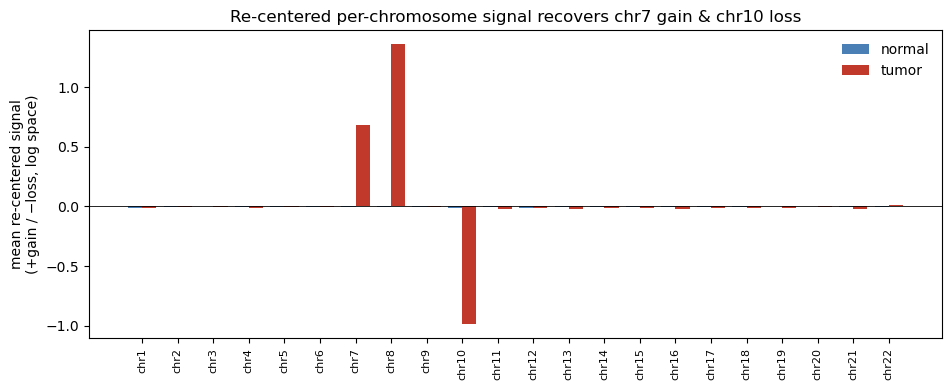

In [8]:
seg_chr = seg["chr"].to_numpy()
seg_ngenes = seg["n_genes"].to_numpy().astype(float)
is_tumor = (pred_aligned["class"] == "tumor").to_numpy()

def chr_profile(mask):
    # Average the per-segment signal within each chromosome, weighting by
    # n_genes: the same length-weighting chr_cnv_matrix.csv uses, so many short
    # segments can't dominate a chromosome's profile.
    seg_mean = centered[mask].mean(axis=0)          # per-segment mean over the cells
    prof = {}
    for c in pd.unique(seg_chr):
        cols = seg_chr == c
        prof[c] = float(np.average(seg_mean[cols], weights=seg_ngenes[cols]))
    return pd.Series(prof)

profile = pd.DataFrame({"normal": chr_profile(is_normal), "tumor": chr_profile(is_tumor)})
# order chromosomes 1..22
profile = profile.reindex([f"chr{i}" for i in range(1, 23) if f"chr{i}" in profile.index])

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(profile))
ax.bar(x - 0.2, profile["normal"], width=0.4, label="normal", color="#4a7fb5")
ax.bar(x + 0.2, profile["tumor"], width=0.4, label="tumor", color="#c0392b")
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(profile.index, rotation=90, fontsize=8)
ax.set_ylabel("mean re-centered signal\n(+gain / −loss, log space)")
ax.set_title("Re-centered per-chromosome signal recovers chr7 gain & chr10 loss")
ax.legend(frameon=False)
plt.show()

## 4. `chr_cnv_matrix.csv`: the ready-to-use per-chromosome summary

If you just want a per-cell × per-chromosome table without any re-centering,
use this file. It is **1.0-centered on a multiplicative scale** (CopyKAT
convention): **1.0 = diploid, >1 = gain, <1 = loss**, and values are always
positive. This is the friendliest file for quick downstream work.

In [9]:
chrm = pd.read_csv(RUN_DIR / "chr_cnv_matrix.csv", index_col="barcode")
chrm_aligned = chrm.reindex(pred.index)
by_class = chrm_aligned.groupby(pred["class"]).mean()
by_class[["chr7", "chr10"]].round(3)

,chr7,chr10
class,,
normal,0.994,0.998
tumor,1.811,0.342


Tumor cells read **> 1 on chr7** (gain) and **< 1 on chr10** (loss); normal
cells sit near 1.0 on both. Same story as the raw matrix, just pre-packaged.

## 5. `tiny_simulated_clones.seg`: an IGV track

A tab-delimited [IGV `.seg`](https://software.broadinstitute.org/software/igv/SEG)
file with one row per (subclone, segment). Load it into IGV to browse the
consensus CNV profile per subclone. Columns: `ID` (`{sample}::{subclone}`),
`chrom`, `loc.start`, `loc.end`, `num.mark`, `seg.mean`.

**Scale note:** `seg.mean` is emitted in the pipeline's native **natural-log**
space (median-centered `log1p` deviation relative to the normal reference), not
the base-2 that the IGV convention nominally expects. IGV renders it on a
diverging color scale, so **sign and relative magnitude read correctly**; only
the absolute base differs. Negatives are losses.

In [10]:
segfile = pd.read_csv(RUN_DIR / "tiny_simulated_clones.seg", sep="\t")
print("subclones in .seg:", segfile["ID"].unique().tolist())
# Consensus signal for subclone_1 on the planted-event chromosomes:
s1 = segfile[segfile["ID"].str.endswith("subclone_1")]
s1[s1["chrom"].isin(["chr7", "chr10"])][["ID", "chrom", "loc.start", "loc.end", "seg.mean"]]

subclones in .seg: ['tiny_simulated::subclone_1', 'tiny_simulated::subclone_2']


,ID,chrom,loc.start,loc.end,seg.mean
15,tiny_simulated::subclone_1,chr7,12704,471947,0.591019
16,tiny_simulated::subclone_1,chr7,484103,1165607,0.589572
17,tiny_simulated::subclone_1,chr7,1169184,5479811,0.601748
18,tiny_simulated::subclone_1,chr7,5495819,6036552,0.627218
22,tiny_simulated::subclone_1,chr10,10781,2015005,-1.069330
23,tiny_simulated::subclone_1,chr10,2040949,3267216,-1.084698
24,tiny_simulated::subclone_1,chr10,3276680,5889906,-1.075626


## 6. `qc.json`: run metadata

Everything about *how* the run went: parameters used, cell/gene counts at each
stage, baseline method, per-step timings, and class/subclone tallies. Handy for
provenance and for spotting problems (e.g. a baseline that fell back, or an
unexpectedly small normal pool).

In [11]:
import json

qc = json.loads((RUN_DIR / "qc.json").read_text())
print("sample:            ", qc["sample"])
print("version:           ", qc.get("kopya_version"))
print("baseline method:   ", qc.get("baseline_method"))
print("cells (loaded to M1):", qc.get("n_cells_loaded"), "to", qc.get("n_cells_post_m1"))
print("n_segments:        ", qc.get("n_segments"))
print("class counts:      ",
      {"tumor": qc.get("n_tumor"), "normal": qc.get("n_normal_called"),
       "uncertain": qc.get("n_uncertain")})

sample:             tiny_simulated
version:            1.0.0
baseline method:    gmm_fallback
cells (loaded to M1): 500 to 500
n_segments:         45
class counts:       {'tumor': 300, 'normal': 200, 'uncertain': 0}


## 7. The genome heatmap

`plot-heatmap` renders an inferCNV-style view directly from a run directory
(it does the re-centering from §3 for you):

```bash
kopya plot-heatmap \
    --run-dir examples/tiny_simulated \
    --out examples/tiny_simulated/heatmap.png --scale linear
```

The committed result: references (confident-diploid normals) on top,
tumor observations below, grouped by subclone. chr7 gain (red) and chr10 loss
(blue) jump out:

![genome heatmap](../examples/tiny_simulated/heatmap.png)

## Recap

| File | Scale | Diploid | Negatives? | Best for |
|------|-------|---------|-----------|----------|
| `prediction.csv` | calls + scores | `tumor_score` ≈ 0 | no | tumor/normal labels |
| `segments.parquet` | log dev (`tumor_mean`) | 0 | **yes** | segment-to-genome map |
| `cn_per_segment.npz` | raw log signal | ~0 after re-centering | **yes** | custom per-cell analysis |
| `chr_cnv_matrix.csv` | 1.0-centered ratio | 1.0 | no | quick per-chromosome work |
| `*_clones.seg` | natural-log ratio | 0 | **yes** | IGV browsing |
| `qc.json` | metadata | n/a | n/a | provenance / debugging |

The two gotchas worth repeating: **`tumor_score` is a within-run rank, not a
portable threshold**, and **`cn_per_segment.npz` must be re-centered** before it
means gain/loss.